# SALT3 Single Spectrum Fitting with Intrinsic Dispersion
This notebook allows you to load a single supernova spectrum, fit it using the SALT3 model with `dynesty` while including an intrinsic dispersion term $\sigma_{\text{sys}}$ in quadrature to capture model mismatch, and visualize the results including convergence plots, corner plots (showing the intrinsic dispersion parameter), and the best-fit model compared to the data.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sncosmo
import dynesty
import corner
from dynesty import plotting as dyplot


SPECTRA_DIR = '../data/all_spectra_dereddened'
PARAM_FILE = "../data/cfasnIa_param.dat"
SNID_RESULTS = "../outputs/method_comparison/cfa_SNID_results.csv"
MODEL_NAME = 'salt3'
NLIVE = 300

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('default')

## 1. Helper Functions

In [2]:
def load_flm_spectrum(file_path):
    data = np.genfromtxt(file_path, invalid_raise=False)
    wave, flux = data[:, 0], data[:, 1]
    err = data[:, 2] if data.shape[1] >= 3 else 0.1 * np.abs(flux)
    mask = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    return wave[mask], flux[mask], err[mask]

In [3]:
def run_fit2(wavelength, flux, flux_err, mjd_obs, nlive, redshift=None):
    model = sncosmo.Model(source=MODEL_NAME)
    if redshift: model.set(z=redshift)

    # Parameter setup: include log_sig_sys
    params = ['t0', 'x1', 'c', 'log_sig_sys']
    
    # Prior bounds for log_sig_sys set based on spectrum flux level
    median_flux = np.median(flux)
    priors = {
        't0': (-30, 30), 
        'x1': (-4, 4), 
        'c': (-1, 1),
        'log_sig_sys': (np.log(1e-4 * median_flux), np.log(10.0 * median_flux))
    }

    # Prior transform
    def pt(u):
        t = np.zeros_like(u)
        for i, p in enumerate(params):
            low, high = priors[p]
            t[i] = u[i] * (high - low) + low
        return t

    # Loglikelihood function
    def ll(t):
        # unpacking
        p_dict = dict(zip(params, t))
        sig_sys = np.exp(p_dict.pop('log_sig_sys'))

        # setting up t0 as an offset
        t0_offset = p_dict.pop('t0')
        t0_mjd = mjd_obs - (t0_offset * (1 + redshift))

        # model setup
        model.set(t0 = t0_mjd)
        model.set(**p_dict)
        model.set(x0=1.0)

        # setup the flux with a x0 of 1
        try:
            m_flux_unit = model.flux(mjd_obs, wavelength)
        except Exception:
            return -1e10

        # setup the weights for the fluxes including the intrinsic dispersion in quadrature
        w = 1.0 / (flux_err**2 + sig_sys**2)

        # setting up the numerator and denominator of the weighted least squares minimization
        num, den = np.sum(flux * m_flux_unit * w), np.sum(m_flux_unit**2 * w)

        # finding the best x0 scaling parameter
        if den <= 0: return -1e10
        x0_best = num / den
        if x0_best <= 0: return -1e10

        # chisq with the added error term in quadrature
        chisq = np.sum(((flux - x0_best * m_flux_unit) ** 2) * w)
        
        # log-determinant normalization for the variable error term
        # (normalized relative to standard errors to avoid giant offset constants and overflow in dynesty plots)
        log_det = np.sum(np.log(1.0 + sig_sys**2 / flux_err**2))

        val = -0.5 * (chisq + log_det)
        return val if not np.isnan(val) else -1e10

    sampler = dynesty.NestedSampler(ll, pt, len(params), nlive=nlive, sample='rwalk')
    sampler.run_nested()
    return sampler.results, params


## 2. Load Data
Select a spectrum from the `data/all_spectra_dereddened` directory.

Found metadata for sn2000B-20000128.13-fast.flm: z=0.0191, mjd_max=51571.13
True Phase: 8.57 d
SNID Phase: 7.35 d
Subtype: nan


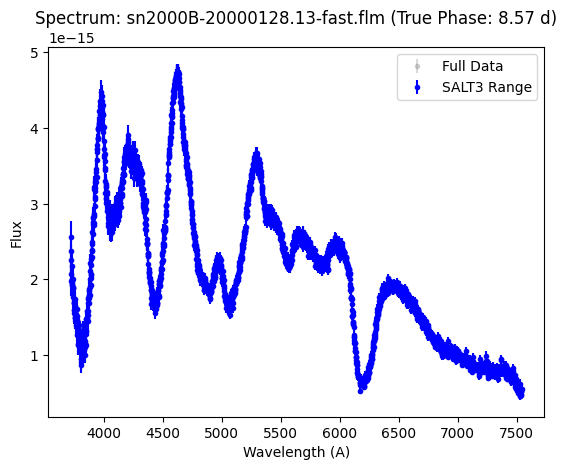

0.0191


In [4]:
# Example file
FILENAME = 'sn2000B-20000128.13-fast.flm'

# Get params from SNID results
true_phase = None
snid_phase = None
mjd_max = None
if os.path.exists(SNID_RESULTS):
    df_snid = pd.read_csv(SNID_RESULTS)
    row = df_snid[df_snid['Filename'] == FILENAME]
    if not row.empty:
        true_phase = row['Age_(days)'].values[0]
        snid_phase = row['bootstrap_age'].values[0]
        subtype = row['Subtype'].values[0]
        mjd_max = row['MJD'].values[0]
        z = row['redshift'].values[0]


if mjd_max is not None:
    print(f"Found metadata for {FILENAME}: z={z}, mjd_max={mjd_max}")
    if true_phase is not None:
        print(f"True Phase: {true_phase:.2f} d")
        print(f"SNID Phase: {snid_phase:.2f} d")
        print(f"Subtype: {subtype}")
    wave, flux, err = load_flm_spectrum(os.path.join(SPECTRA_DIR, FILENAME))
    
    # Apply SALT3 wavelength range mask
    mask = (wave > 3500) & (wave < 8000)
    wave_f, flux_f, err_f = wave[mask], flux[mask], err[mask]
    
    plt.errorbar(wave, flux, yerr=err, fmt='.', color='gray', alpha=0.3, label='Full Data')
    plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='blue', label='SALT3 Range')
    title = f"Spectrum: {FILENAME}"
    if true_phase is not None: title += f" (True Phase: {true_phase:.2f} d)"
    plt.title(title)
    plt.xlabel("Wavelength (A)")
    plt.ylabel("Flux")
    plt.legend()
    plt.show()
else:
    print(f"Error: Metadata for {sn_id} not found in {PARAM_FILE}")

print(z)

## 3. Run Nested Sampling

In [5]:
results, params_names = run_fit2(wave_f, flux_f, err_f, mjd_max, NLIVE, redshift=z)
print("Fit complete.")

iter: 1 | bound: 0 | nc: 1 | ncall: 301 | eff(%):  0.332 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-  3.341 | dlogz:    inf >  0.309                                                      

iter: 2 | bound: 0 | nc: 1 | ncall: 302 | eff(%):  0.662 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-    nan | dlogz:    inf >  0.309                                                      

iter: 3 | bound: 0 | nc: 1 | ncall: 303 | eff(%):  0.990 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-  3.495 | dlogz:    inf >  0.309                                                      

iter: 4 | bound: 0 | nc: 1 | ncall: 304 | eff(%):  1.316 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-    nan | dlogz:    inf >  0.309                                                      

iter: 5 | bound: 0 | nc: 1 | ncall: 305 | eff(%):  1.639 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-    nan | dlogz:    inf >  0.309                                                      

...

iter: 6404 | +297 | bound: 18 | nc: 1 | ncall: 139074 | eff(%):  4.829 | loglstar:   -inf < -4767.673 <    inf | logz: -4787.740 +/-    nan | dlogz:  0.004 >  0.309                                  

iter: 6404 | +298 | bound: 18 | nc: 1 | ncall: 139075 | eff(%):  4.829 | loglstar:   -inf < -4767.662 <    inf | logz: -4787.739 +/-    nan | dlogz:  0.003 >  0.309                                  

iter: 6404 | +299 | bound: 18 | nc: 1 | ncall: 139076 | eff(%):  4.830 | loglstar:   -inf < -4767.659 <    inf | logz: -4787.739 +/-    nan | dlogz:  0.002 >  0.309                                  

iter: 6404 | +300 | bound: 18 | nc: 1 | ncall: 139077 | eff(%):  4.831 | loglstar:   -inf < -4767.621 <    inf | logz: -4787.738 +/-    nan | dlogz:  0.001 >  0.309                                  

Fit complete.


## 4. Convergence Plots
Check if the evidence has converged and look at the parameter traces.

/Users/pxm588@student.bham.ac.uk/miniconda3/envs/testsuite/lib/python3.13/site-packages/dynesty/plotting.py:318: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[i].set_ylim([ymin, ymax])


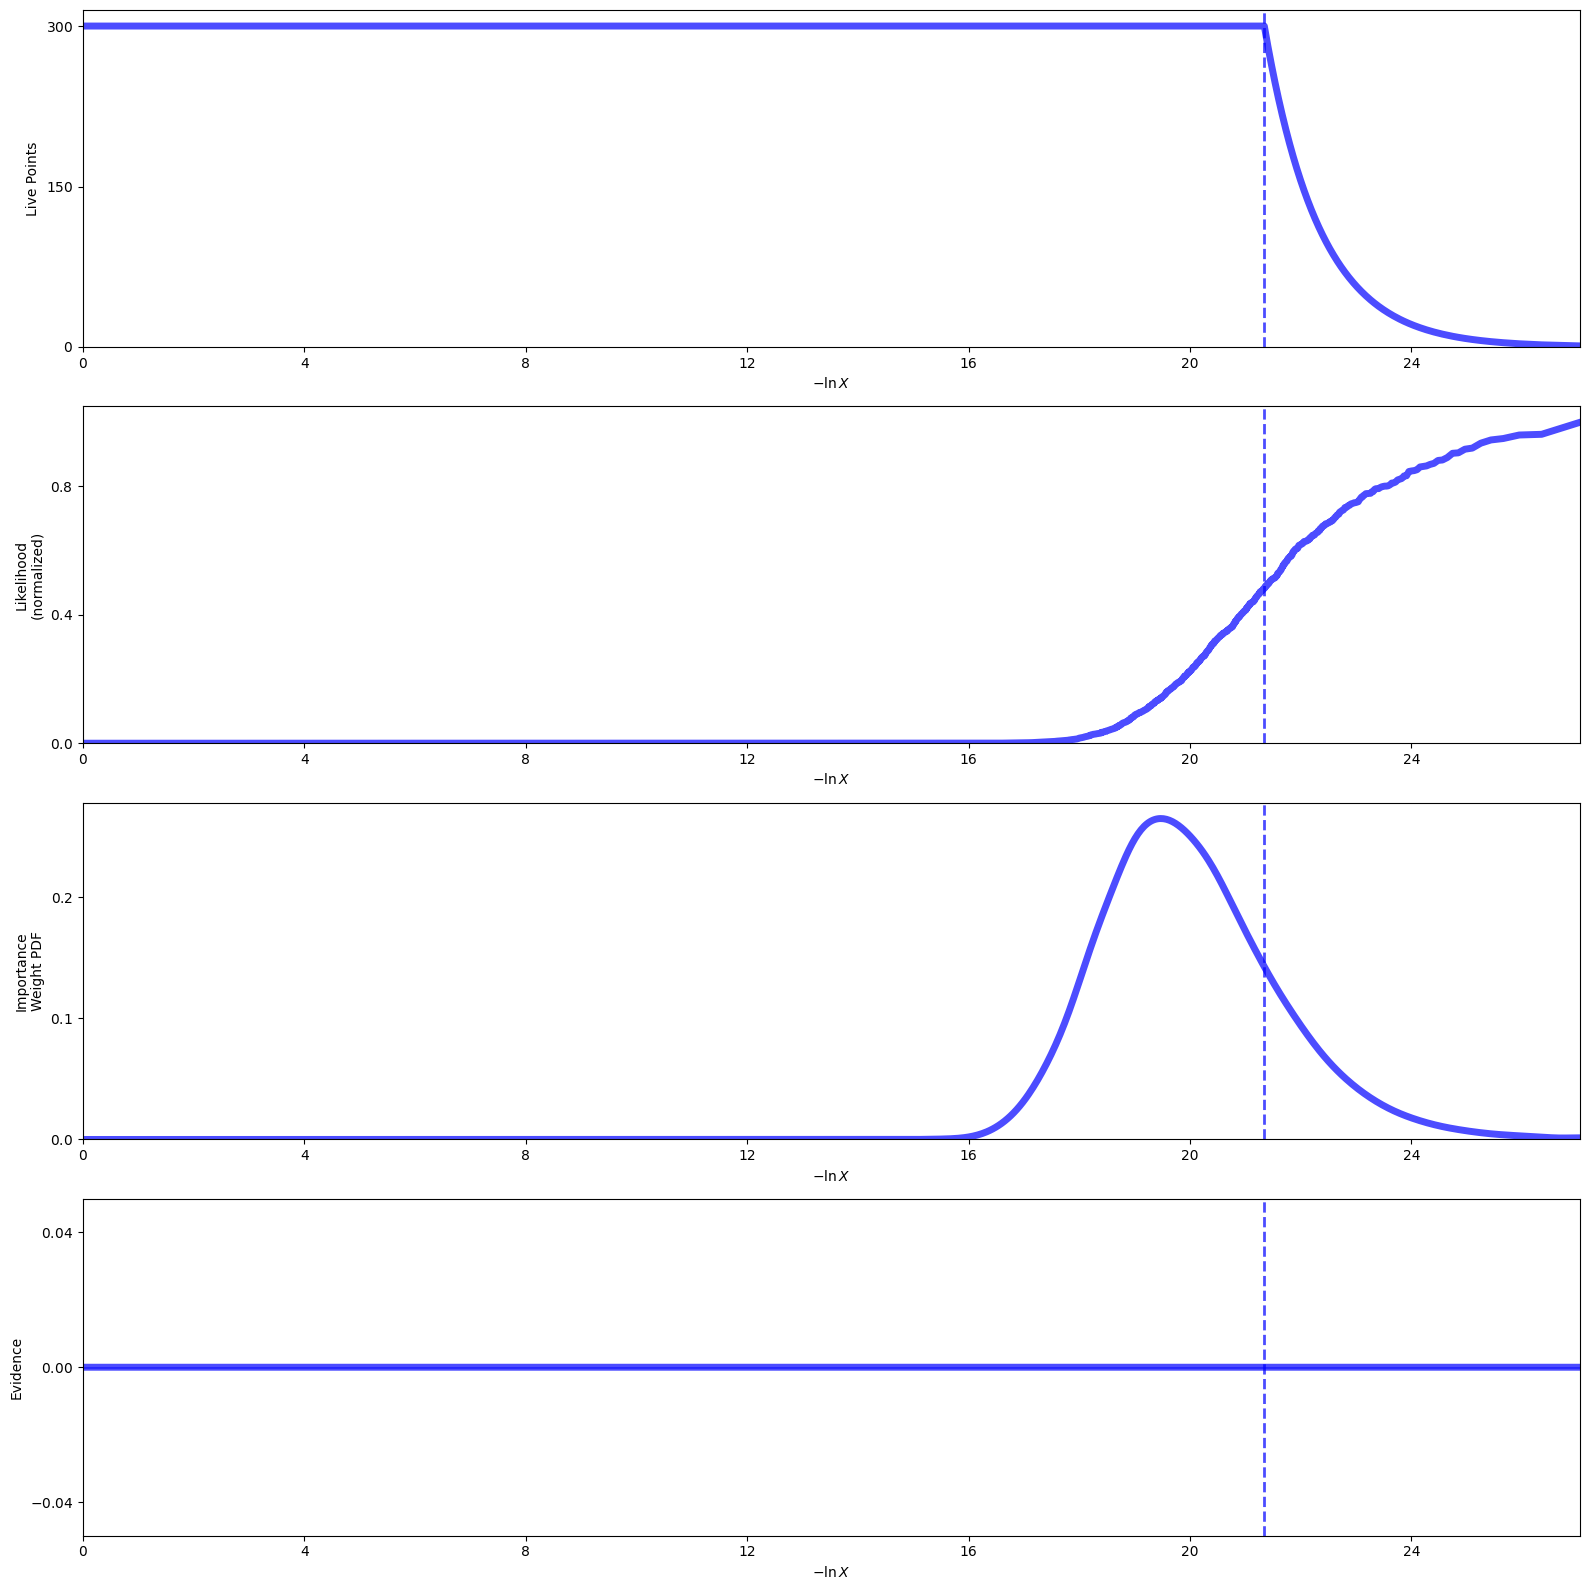

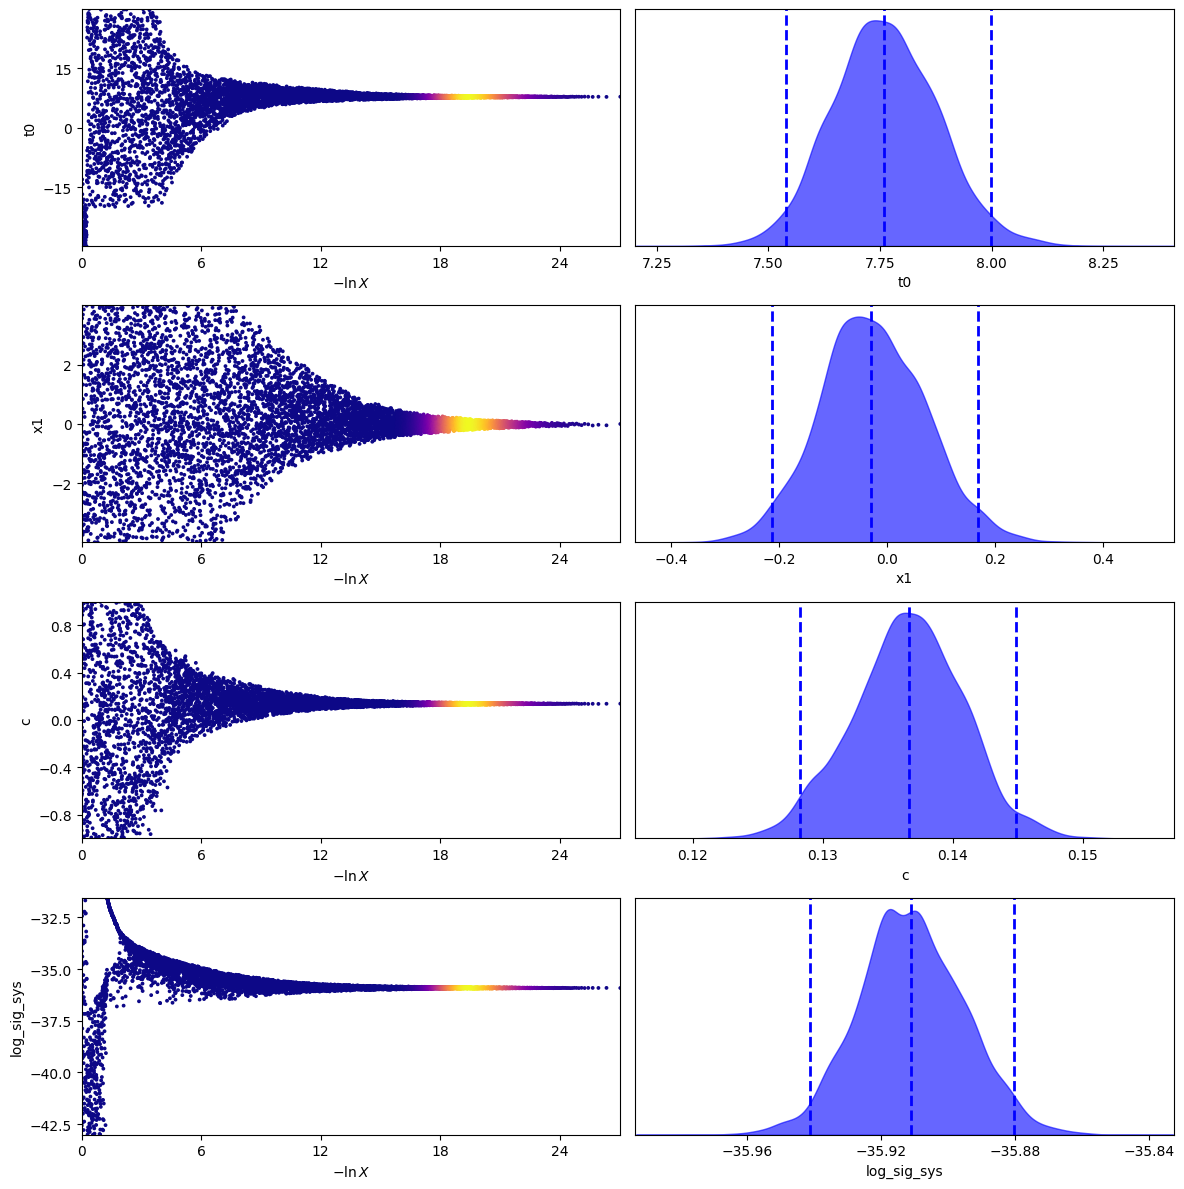

In [6]:
fig, axes = dyplot.runplot(results)
plt.tight_layout()
plt.show()

fig, axes = dyplot.traceplot(results, labels=params_names)
plt.tight_layout()
plt.show()

## 5. Corner Plot
Visualize parameter correlations and marginalized distributions.

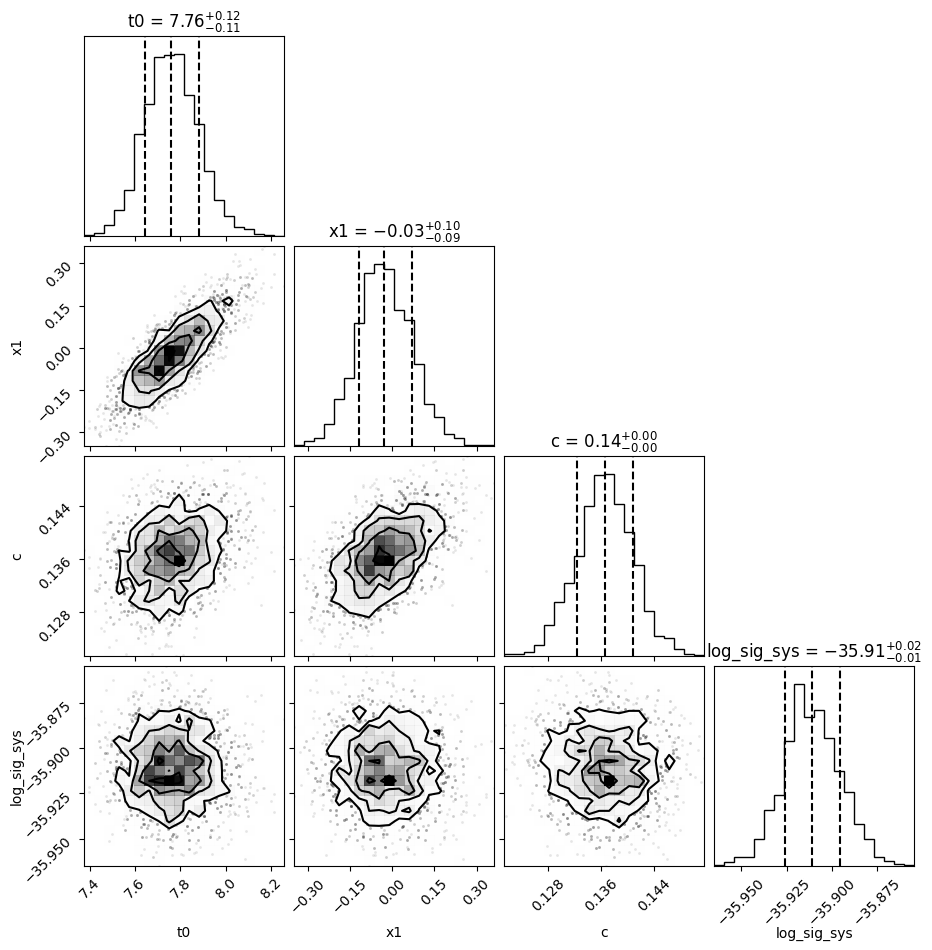

In [7]:
# Resample for equal weights
weights = np.exp(results.logwt - results.logz[-1])
samples = dynesty.utils.resample_equal(results.samples, weights)

fig = corner.corner(samples, labels=params_names, quantiles=[0.16, 0.5, 0.84], show_titles=True)
plt.show()

## 6. Model vs Data
Overlay the best-fit model on the observed spectrum.

Median sig_sys: 2.535e-16


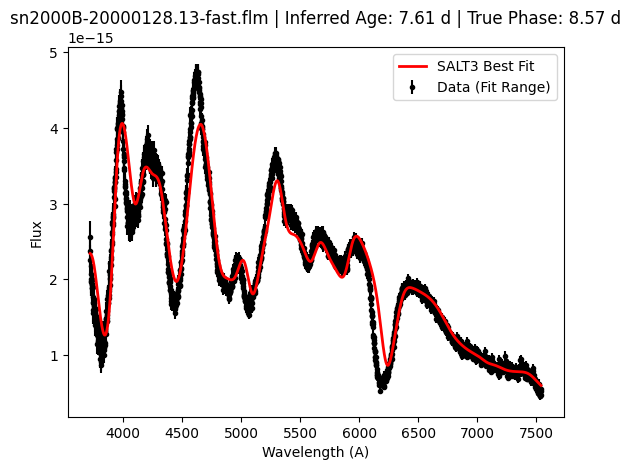

In [8]:
# Get median parameters
med_params = np.median(samples, axis=0)
p_dict = dict(zip(params_names, med_params))

model = sncosmo.Model(source=MODEL_NAME)
model.set(z=z)

# Extract and pop log_sig_sys from p_dict before setting model parameters
sig_sys_median = np.exp(p_dict.pop('log_sig_sys'))
print(f"Median sig_sys: {sig_sys_median:.3e}")

model.set(**p_dict)

t0_offset = p_dict['t0']
t0_mjd = mjd_max - t0_offset * (1 + z)   # undo the transform from run_fit2

model.set(t0=t0_mjd)
model.set(x1=p_dict['x1'], c=p_dict['c'])
model.set(x0=1.0)
m_flux_unit = model.flux(mjd_max, wave_f)  # evaluate at the observation epoch

# Compute best x0 using weights with intrinsic dispersion included in quadrature
w = 1.0 / (err_f**2 + sig_sys_median**2)
x0_best = np.sum(flux_f * m_flux_unit * w) / np.sum(m_flux_unit**2 * w)
model.set(x0=x0_best)

model_flux = m_flux_unit * x0_best

plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black', label='Data (Fit Range)')
plt.plot(wave_f, model_flux, color='red', lw=2, label='SALT3 Best Fit', zorder=10)

inferred_age = (p_dict['t0']) / (1 + z)
plt.title(f"{FILENAME} | Inferred Age: {inferred_age:.2f} d | True Phase: {true_phase:.2f} d" if true_phase is not None else f"{FILENAME} | Inferred Age: {inferred_age:.2f} d")
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.legend()
plt.show()


In [9]:
SNID_DIR = '/Users/pxm588@student.bham.ac.uk/Desktop/snid/cfa_pipeline/all_spectra_dereddened_snidded_supersnid'

# The number of the comp file we want to pick
no = '01'

base_filename = FILENAME.rsplit('.', 1)[0]

snid_output_name = f"{base_filename}_comp00{no}_snidflux.dat"

compfile = os.path.join(SNID_DIR, snid_output_name)


compwave, compflux, comperr = load_flm_spectrum(compfile)
mask = (compwave > 3500) & (compwave < 8000)
compwave_f, compflux_f, comperr_f = compwave[mask], compflux[mask], comperr[mask]


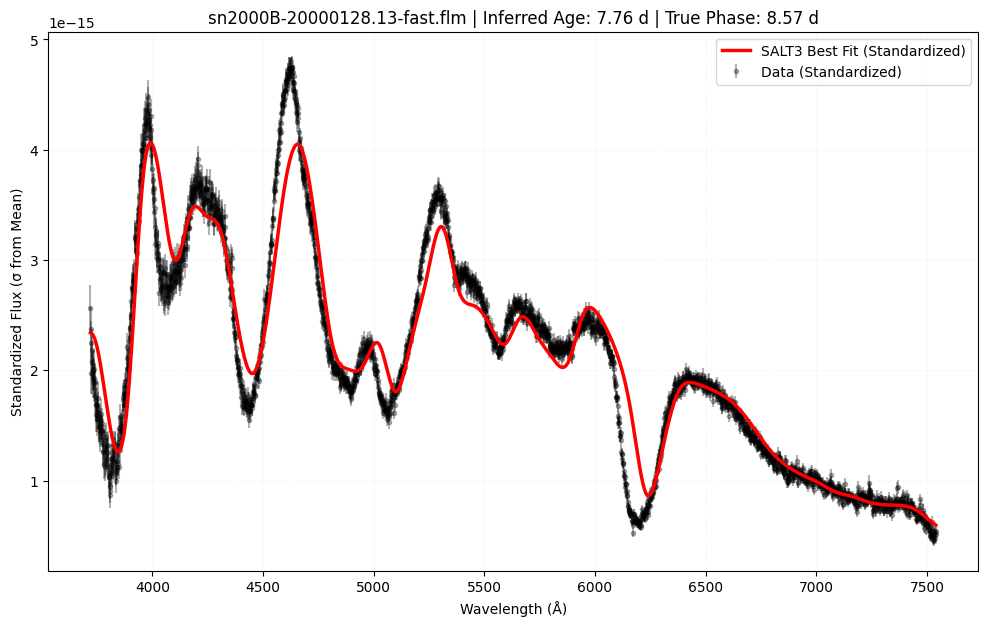

In [10]:
plt.figure(figsize=(12, 7))

# 1. Observed Data (Grey/Black dots)
plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black',
             alpha=0.3, label='Data (Standardized)', zorder=1)

# 2. SALT3 Model (Bold Red line)
plt.plot(wave_f, model_flux, color='red', lw=2.5,
         label='SALT3 Best Fit (Standardized)', zorder=10)

# # 3. SNID Fit (Blue dots/line)
# plt.errorbar(compwave_f, compflux_f, yerr=comperr_f, fmt='.', color='blue',
#              alpha=0.4, label='Best SNID fit (Standardized)', zorder=5)

# Visual anchors
# plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(alpha=0.2, linestyle=':')

# Metadata and labeling
inferred_age = (p_dict['t0'])
title_str = f"{FILENAME} | Inferred Age: {inferred_age:.2f} d"
if true_phase is not None:
    title_str += f" | True Phase: {true_phase:.2f} d"

plt.title(title_str)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Standardized Flux (σ from Mean)")
plt.legend(loc='upper right', frameon=True)
plt.show()

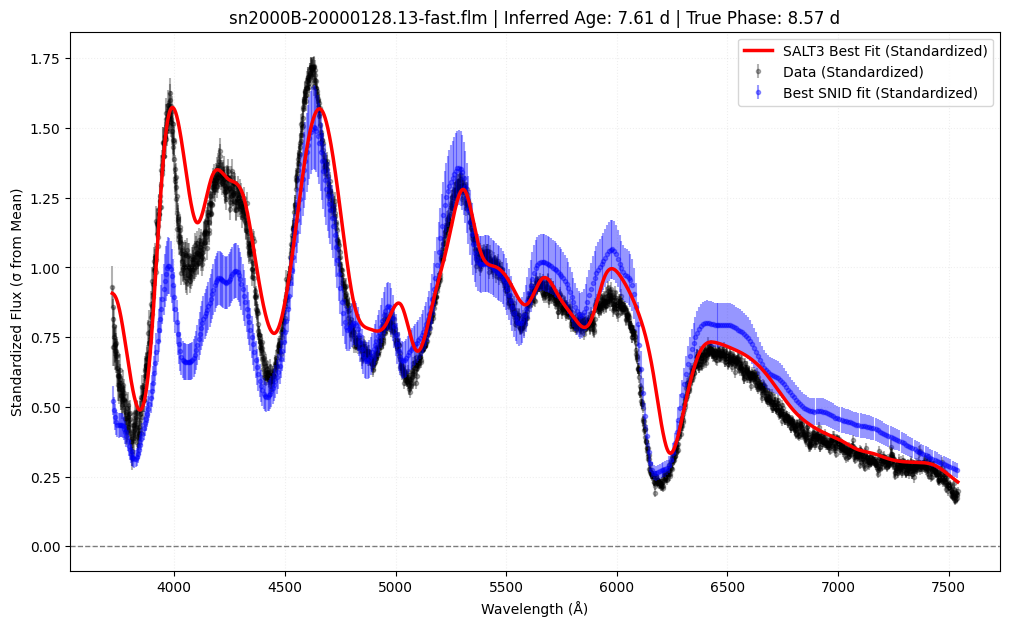

In [11]:
# --- Scalar Normalization (Preserves Continuum & Feature Depth) ---
def normalize_flux(wave, flux, error=None, wmin=5000, wmax=5500):
    """
    Scales the spectrum so the median flux in the chosen wavelength 
    window (wmin to wmax) is exactly 1.0.
    """
    # 1. Create a mask for the anchor window
    mask = (wave >= wmin) & (wave <= wmax)
    
    # Fallback: if the spectrum doesn't cover the window, use the whole array
    if not np.any(mask):
        mask = np.ones(len(wave), dtype=bool)

    # 2. Find the median flux in that window (median ignores noise spikes)
    scale_factor = np.median(flux[mask])

    # 3. Scale the flux
    norm_flux = flux / scale_factor

    if error is not None:
        # Errors must be scaled by the same factor
        norm_error = error / scale_factor
        return norm_flux, norm_error
    
    return norm_flux

# Process all three datasets using the new function
flux_f_norm, err_f_norm = normalize_flux(wave_f, flux_f, err_f)
model_flux_norm = normalize_flux(wave_f, model_flux) # Assuming model uses same wave grid
compflux_f_norm, comperr_f_norm = normalize_flux(compwave_f, compflux_f, comperr_f)
# -----------------------------------------------------------
plt.figure(figsize=(12, 7))

# 1. Observed Data (Grey/Black dots)
plt.errorbar(wave_f, flux_f_norm, yerr=err_f_norm, fmt='.', color='black',
             alpha=0.3, label='Data (Standardized)', zorder=1)

# 2. SALT3 Model (Bold Red line)
plt.plot(wave_f, model_flux_norm, color='red', lw=2.5,
         label='SALT3 Best Fit (Standardized)', zorder=10)

# 3. SNID Fit (Blue dots/line)
plt.errorbar(compwave_f, compflux_f_norm, yerr=comperr_f_norm, fmt='.', color='blue',
             alpha=0.4, label='Best SNID fit (Standardized)', zorder=5)

# Visual anchors
plt.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.5)
plt.grid(alpha=0.2, linestyle=':')

# Metadata and labeling
inferred_age = (p_dict['t0']) / (1 + z)
title_str = f"{FILENAME} | Inferred Age: {inferred_age:.2f} d"
if true_phase is not None:
    title_str += f" | True Phase: {true_phase:.2f} d"

plt.title(title_str)
plt.xlabel("Wavelength (Å)")
plt.ylabel("Standardized Flux (σ from Mean)")
plt.legend(loc='upper right', frameon=True)
plt.show()

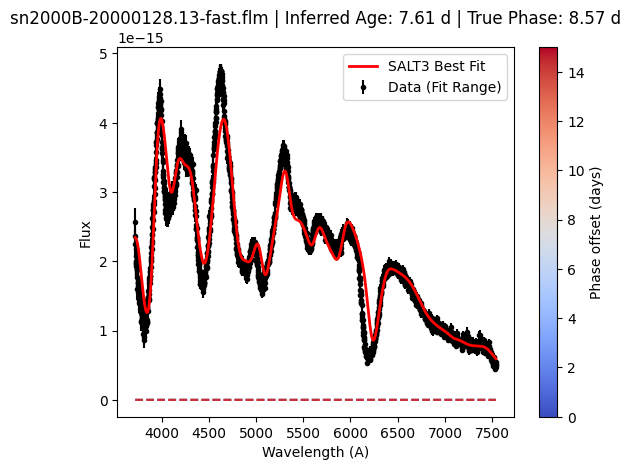

In [12]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

t_values = np.arange(0, 16, 1)
norm = Normalize(vmin=t_values.min(), vmax=t_values.max())
cmap = plt.cm.coolwarm

for t in t_values:
    color = cmap(norm(t))
    plt.plot(wave_f, model.flux(t, wave_f),
             color=color, linestyle='--', alpha=0.5)

plt.errorbar(wave_f, flux_f, yerr=err_f, fmt='.', color='black', label='Data (Fit Range)')
plt.plot(wave_f, model_flux, color='red', lw=2, label='SALT3 Best Fit', zorder=10)

sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, label='Phase offset (days)', ax=plt.gca())

inferred_age = (p_dict['t0']) / (1 + z)
plt.title(f"{FILENAME} | Inferred Age: {inferred_age:.2f} d | True Phase: {true_phase:.2f} d" if true_phase is not None else f"{FILENAME} | Inferred Age: {inferred_age:.2f} d")
plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")
plt.legend()
plt.show()